# 01 - Getting started

This notebook introduces the basics of `evtolpy`. We'll load a configuration file, create an `Aircraft` object, and inspect a few key properties.

## What is evtolpy?

`evtolpy` is a Python framework for conceptual design and performance analysis of electric vertical takeoff and landing (eVTOL) aircraft. Given a vehicle configuration and flight mission, it computes:

- Aerodynamic properties
- Power requirements
- Energy consumption across the full mission profile
- Mass breakdown and iterative MTOW convergence

All inputs are specified in a single JSON configuration file.

## How the Computation Works

The framework follows a three-step power chain for every mission segment:

**Step 1 -- Shaft Power.** Compute the mechanical power required at the rotor shaft. Each segment uses a different formula depending on whether the aircraft is hovering, climbing, cruising, or descending. The general form is:

$$P_{shaft,avg} = \frac{F_h \cdot v_h + F_v \cdot v_v}{\eta_{rotor}}$$

where $F_h$ and $F_v$ are horizontal and vertical force components, and $\eta_{rotor}$ is rotor efficiency.

**Step 2 -- Electric Power.** Convert shaft power to electric power by dividing by the EPU (Electric Propulsion Unit) efficiency:

$$P_{elec,avg} = \frac{P_{shaft,avg}}{\eta_{epu}}$$

**Step 3 -- Energy.** Integrate electric power over the segment duration to get energy consumption:

$$E = P_{elec,avg} \cdot t$$

The total mission energy (primary + reserve) or the maximum power requirement (C-rate) then drives battery sizing, which feeds back into MTOW iteration.

## Setup

First, we add the `evtol` package to the Python path and import the `Aircraft` class.

In [13]:
import sys
sys.path.append('../../evtol')
from aircraft import Aircraft

## Loading a Configuration

The `Aircraft` class takes a path to a JSON file. Here we load the **Archer Midnight** configuration: a lift-plus-cruise eVTOL with 12 rotors (6 lift + 6 tilt) and a 15.24 m wingspan.

In [14]:
aircraft = Aircraft('../Archer_Midnight.json')

## Inspecting Basic Properties

The `Aircraft` object has many different properties, here are some important ones.

In [15]:
print(f"Max Takeoff Mass:  {aircraft.max_takeoff_mass_kg:.1f} kg")
print(f"Payload:           {aircraft.payload_kg:.1f} kg")
print(f"Wingspan:          {aircraft.wingspan_m:.1f} m")
print(f"Fuselage Length:   {aircraft.fuselage_l_m:.2f} m")
print(f"Fuselage Width:    {aircraft.fuselage_w_m:.2f} m")
print(f"Stall Speed:       {aircraft.stall_speed_m_p_s:.1f} m/s")

Max Takeoff Mass:  2948.3 kg
Payload:           453.0 kg
Wingspan:          15.2 m
Fuselage Length:   9.00 m
Fuselage Width:    1.60 m
Stall Speed:       40.0 m/s


## Derived Properties

`evtolpy` automatically computes derived quantities from the input parameters. These are exposed as Python `@property` attributes.

In [16]:
print(f"Wing Area:           {aircraft.wing_area_m2:.2f} m^2")
print(f"Wing Aspect Ratio:   {aircraft.wing_aspect_ratio:.2f}")
print(f"Cruise CL:           {aircraft.cruise_cl:.4f}")
print(f"Cruise CD:           {aircraft.cruise_cd:.6f}")
print(f"Cruise L/D:          {aircraft.cruise_l_p_d:.2f}")
print(f"Hover Shaft Power:   {aircraft.hover_shaft_power_kw:.2f} kW")

Wing Area:           19.68 m^2
Wing Aspect Ratio:   11.80
Cruise CL:           0.5355
Cruise CD:           0.051402
Cruise L/D:          10.42
Hover Shaft Power:   691.66 kW


## Archer Midnight Summary

The following chart summarizes the key performance parameters of the Archer Midnight. These numbers result from the full computation pipeline: geometry drives aerodynamics, aerodynamics drives power, and power drives energy and battery sizing.

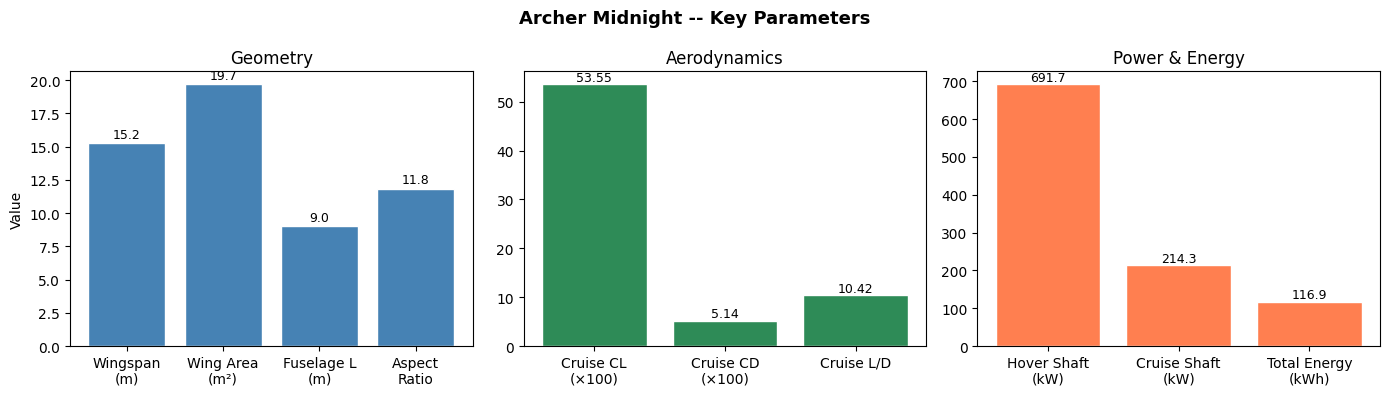

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: Geometry
geom_labels = ['Wingspan\n(m)', 'Wing Area\n(m²)', 'Fuselage L\n(m)', 'Aspect\nRatio']
geom_values = [aircraft.wingspan_m, aircraft.wing_area_m2, aircraft.fuselage_l_m, aircraft.wing_aspect_ratio]
bars = axes[0].bar(geom_labels, geom_values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, geom_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Geometry')
axes[0].set_ylabel('Value')

# Panel 2: Aerodynamics
aero_labels = ['Cruise CL\n(×100)', 'Cruise CD\n(×100)', 'Cruise L/D']
aero_values = [aircraft.cruise_cl*100,aircraft.cruise_cd * 100, aircraft.cruise_l_p_d]
bars = axes[1].bar(aero_labels, aero_values, color='seagreen', edgecolor='white')
for bar, val in zip(bars, aero_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Aerodynamics')

# Panel 3: Power
power_labels = ['Hover Shaft\n(kW)', 'Cruise Shaft\n(kW)', 'Total Energy\n(kWh)']
power_values = [aircraft.hover_shaft_power_kw,
                aircraft.cruise_avg_shaft_power_kw,
                aircraft.total_mission_energy_kw_hr + aircraft.total_reserve_mission_energy_kw_hr]
bars = axes[2].bar(power_labels, power_values, color='coral', edgecolor='white')
for bar, val in zip(bars, power_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)
axes[2].set_title('Power & Energy')

fig.suptitle('Archer Midnight -- Key Parameters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Class Composition

The `Aircraft` class contains four sub-objects that group related parameters:

| Sub-object | Purpose | Feeds into... |
|---|---|---|
| `aircraft.environ` | Atmospheric conditions (gravity, air density, viscosity) | Aerodynamics, hover power |
| `aircraft.mission` | Flight segment definitions (velocities, durations) | Segment power & energy |
| `aircraft.power` | Battery and EPU characteristics | Electric power, battery mass |
| `aircraft.propulsion` | Rotor system parameters | Shaft power, disk loading |

Each sub-object is populated from its corresponding section in the JSON file. The `Aircraft` class itself holds the top-level vehicle parameters (geometry, masses, aerodynamics) and computes all derived quantities.

In [18]:
print("--- Environ ---")
print(f"  Gravity:          {aircraft.environ.g_m_p_s2} m/s^2")
print(f"  Air density (SL): {aircraft.environ.air_density_sea_lvl_kg_p_m3} kg/m^3")

print("\n--- Power ---")
print(f"  Battery spec energy: {aircraft.power.batt_spec_energy_w_h_p_kg} Wh/kg")
print(f"  EPU efficiency:      {aircraft.power.epu_effic}")

print("\n--- Propulsion ---")
print(f"  Rotor count:    {aircraft.propulsion.rotor_count}")
print(f"  Rotor diameter: {aircraft.propulsion.rotor_diameter_m} m")
print(f"  Disk area:      {aircraft.propulsion.disk_area_m2:.2f} m^2")

print("\n--- Mission ---")
print(f"  Cruise speed:    {aircraft.mission.cruise_h_m_p_s} m/s")
print(f"  Cruise duration: {aircraft.mission.cruise_s} s")

--- Environ ---
  Gravity:          9.81 m/s^2
  Air density (SL): 1.225 kg/m^3

--- Power ---
  Battery spec energy: 256.0 Wh/kg
  EPU efficiency:      0.92

--- Propulsion ---
  Rotor count:    12
  Rotor diameter: 2.0 m
  Disk area:      37.70 m^2

--- Mission ---
  Cruise speed:    66.9444 m/s
  Cruise duration: 558.0 s


## Summary

In this notebook we learned how to:

- Import the `Aircraft` class and load a JSON configuration
- Access input parameters (e.g., `max_takeoff_mass_kg`, `wingspan_m`)
- Access derived properties (e.g., `wing_area_m2`, `cruise_l_p_d`)
- Explore the four sub-objects: `environ`, `mission`, `power`, `propulsion`

**Next:** [02 - Exploring the JSON Configuration]